# scGen Training Analysis

Examines the HDF5 `scalars` files from scGen training runs to assess convergence.

**Runs analyzed:**
- **CPU run** (`cellot/cellot/results/cross_species_ood_scgen/`) — timed out at ~38%
- **GPU run** (`cellot/cellot_gpu/results/cross_species_ood_scgen_gpu/`) — cancelled at ~40%
- **Previous CellOT run** (`cellot/cellot/results/cross_species_ood/`) — completed (no scGen embedding)

In [2]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

BASE = '/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot'

## 1. Reading HDF5 scalars

The training loop writes loss metrics to an HDF5 file at `cache/scalars` using `pd.DataFrame.to_hdf(..., append=True)`.  
Two keys exist: `"train"` (logged every `logs_freq=250` steps) and `"eval"` (logged every `eval_freq=2500` steps).

In [3]:
def load_scalars(result_dir):
    """Load train and eval scalars from a results directory."""
    path = f'{result_dir}/cache/scalars'
    train = pd.read_hdf(path, key='train')
    eval_ = pd.read_hdf(path, key='eval')
    return train, eval_

# Load both runs
cpu_train, cpu_eval = load_scalars(f'{BASE}/cellot/results/cross_species_ood_scgen')
gpu_train, gpu_eval = load_scalars(f'{BASE}/cellot_gpu/results/cross_species_ood_scgen_gpu')

print('CPU run:')
print(f'  Train: {len(cpu_train)} entries, steps {cpu_train.index.min():.0f}–{cpu_train.index.max():.0f}')
print(f'  Eval:  {len(cpu_eval)} entries, steps {cpu_eval.index.min():.0f}–{cpu_eval.index.max():.0f}')
print(f'  Columns: {list(cpu_train.columns)}')

print('\nGPU run:')
print(f'  Train: {len(gpu_train)} entries, steps {gpu_train.index.min():.0f}–{gpu_train.index.max():.0f}')
print(f'  Eval:  {len(gpu_eval)} entries, steps {gpu_eval.index.min():.0f}–{gpu_eval.index.max():.0f}')
print(f'  Columns: {list(gpu_train.columns)}')

CPU run:
  Train: 361 entries, steps 0–90000
  Eval:  37 entries, steps 0–90000
  Columns: ['loss', 'mse', 'reg']

GPU run:
  Train: 401 entries, steps 0–100000
  Eval:  41 entries, steps 0–100000
  Columns: ['loss', 'mse', 'reg']


## 2. Eval loss convergence

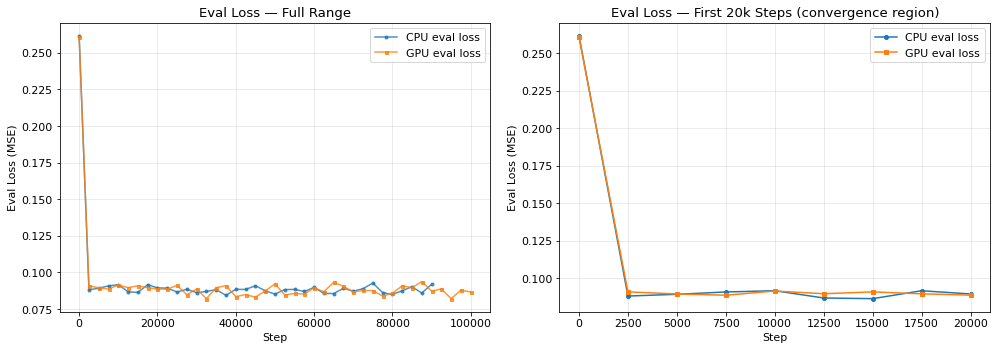

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full view
ax = axes[0]
ax.plot(cpu_eval.index, cpu_eval['loss'], 'o-', ms=3, label='CPU eval loss', alpha=0.8)
ax.plot(gpu_eval.index, gpu_eval['loss'], 's-', ms=3, label='GPU eval loss', alpha=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Eval Loss (MSE)')
ax.set_title('Eval Loss — Full Range')
ax.legend()

# Zoomed to first 20k steps
ax = axes[1]
mask_cpu = cpu_eval.index <= 20000
mask_gpu = gpu_eval.index <= 20000
ax.plot(cpu_eval.index[mask_cpu], cpu_eval['loss'][mask_cpu], 'o-', ms=4, label='CPU eval loss')
ax.plot(gpu_eval.index[mask_gpu], gpu_eval['loss'][mask_gpu], 's-', ms=4, label='GPU eval loss')
ax.set_xlabel('Step')
ax.set_ylabel('Eval Loss (MSE)')
ax.set_title('Eval Loss — First 20k Steps (convergence region)')
ax.legend()

plt.tight_layout()
plt.savefig('/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/analysis/scgen_eval_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Train loss convergence

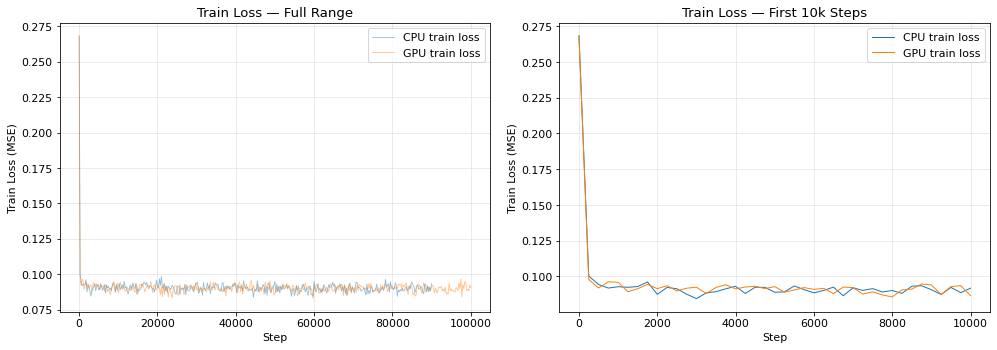

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cpu_train.index, cpu_train['loss'], '-', alpha=0.5, lw=0.8, label='CPU train loss')
ax.plot(gpu_train.index, gpu_train['loss'], '-', alpha=0.5, lw=0.8, label='GPU train loss')
ax.set_xlabel('Step')
ax.set_ylabel('Train Loss (MSE)')
ax.set_title('Train Loss — Full Range')
ax.legend()

ax = axes[1]
mask_cpu = cpu_train.index <= 10000
mask_gpu = gpu_train.index <= 10000
ax.plot(cpu_train.index[mask_cpu], cpu_train['loss'][mask_cpu], '-', lw=1, label='CPU train loss')
ax.plot(gpu_train.index[mask_gpu], gpu_train['loss'][mask_gpu], '-', lw=1, label='GPU train loss')
ax.set_xlabel('Step')
ax.set_ylabel('Train Loss (MSE)')
ax.set_title('Train Loss — First 10k Steps')
ax.legend()

plt.tight_layout()
plt.savefig('/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/analysis/scgen_train_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Best model checkpoints

In [6]:
for name, result_dir in [
    ('CPU', f'{BASE}/cellot/results/cross_species_ood_scgen'),
    ('GPU', f'{BASE}/cellot_gpu/results/cross_species_ood_scgen_gpu'),
]:
    model_ckpt = torch.load(f'{result_dir}/cache/model.pt', map_location='cpu')
    last_ckpt = torch.load(f'{result_dir}/cache/last.pt', map_location='cpu')
    
    best_step = model_ckpt.get('step', 'N/A')
    best_loss = model_ckpt.get('eval_loss', 'N/A')
    last_step = last_ckpt.get('step', 'N/A')
    
    print(f'{name} run:')
    print(f'  Best model (model.pt): step={best_step}, eval_loss={best_loss}')
    print(f'  Last checkpoint (last.pt): step={last_step}')
    print()

CPU run:
  Best model (model.pt): step=37501, eval_loss=0.08427082002162933
  Last checkpoint (last.pt): step=90001

GPU run:
  Best model (model.pt): step=32501, eval_loss=0.08204484730958939
  Last checkpoint (last.pt): step=100001



## 5. Convergence summary

Eval loss as a table — confirms the model plateaus early.

In [7]:
summary = pd.DataFrame({
    'GPU eval_loss': gpu_eval['loss'],
    'CPU eval_loss': cpu_eval['loss'],
}).rename_axis('step')

# Running minimum to show when the best was achieved
summary['GPU running_min'] = summary['GPU eval_loss'].cummin()
summary['CPU running_min'] = summary['CPU eval_loss'].cummin()

print(summary.to_string(float_format='%.6f'))
print(f'\nGPU best: {gpu_eval["loss"].min():.6f} at step {int(gpu_eval["loss"].idxmin())}')
print(f'CPU best: {cpu_eval["loss"].min():.6f} at step {int(cpu_eval["loss"].idxmin())}')

          GPU eval_loss  CPU eval_loss  GPU running_min  CPU running_min
step                                                                    
0.0            0.260669       0.261617         0.260669         0.261617
2500.0         0.090827       0.088036         0.090827         0.088036
5000.0         0.089410       0.089200         0.089410         0.088036
7500.0         0.088590       0.090756         0.088590         0.088036
10000.0        0.091384       0.091600         0.088590         0.088036
12500.0        0.089578       0.086737         0.088590         0.086737
15000.0        0.090807       0.086301         0.088590         0.086301
17500.0        0.089526       0.091579         0.088590         0.086301
20000.0        0.088631       0.089426         0.088590         0.086301
22500.0        0.088506       0.089214         0.088506         0.086301
25000.0        0.091090       0.086561         0.088506         0.086301
27500.0        0.084766       0.088480         0.08

## 6. Previous CellOT run (without scGen embedding)

An earlier CellOT run completed all 100k iterations directly on gene expression space (no scGen latent embedding). Included here for reference.

CellOT train: 2000 entries, steps 0–99950
CellOT eval:  400 entries, steps 0–99750
  Eval columns: ['gloss', 'floss', 'jloss', 'mmd']
  Best MMD: 0.015835 at step 2000


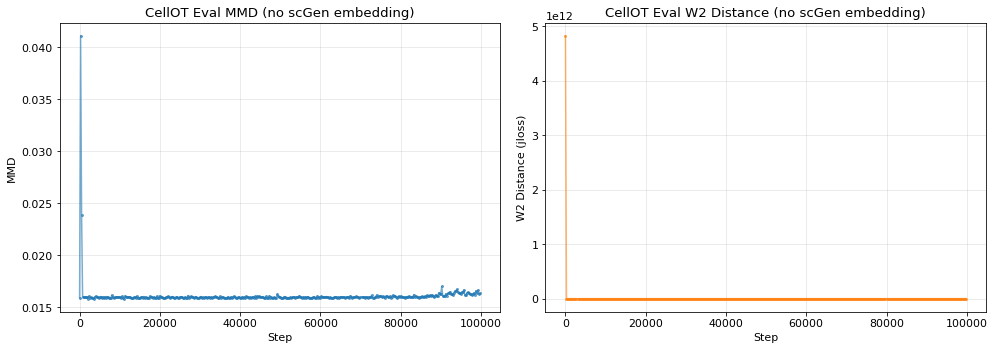

In [8]:

cellot_path = f'{BASE}/cellot/results/cross_species_ood/cache/scalars'

cellot_train = pd.read_hdf(cellot_path, key='train')
cellot_eval = pd.read_hdf(cellot_path, key='eval')

print(f'CellOT train: {len(cellot_train)} entries, steps {cellot_train.index.min():.0f}–{cellot_train.index.max():.0f}')
print(f'CellOT eval:  {len(cellot_eval)} entries, steps {cellot_eval.index.min():.0f}–{cellot_eval.index.max():.0f}')
print(f'  Eval columns: {list(cellot_eval.columns)}')
print(f'  Best MMD: {cellot_eval["mmd"].min():.6f} at step {int(cellot_eval["mmd"].idxmin())}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cellot_eval.index, cellot_eval['mmd'], 'o-', ms=2, alpha=0.6)
ax.set_xlabel('Step')
ax.set_ylabel('MMD')
ax.set_title('CellOT Eval MMD (no scGen embedding)')

ax = axes[1]
ax.plot(cellot_eval.index, cellot_eval['jloss'], 'o-', ms=2, alpha=0.6, color='tab:orange')
ax.set_xlabel('Step')
ax.set_ylabel('W2 Distance (jloss)')
ax.set_title('CellOT Eval W2 Distance (no scGen embedding)')

plt.tight_layout()
plt.savefig('/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/analysis/cellot_previous_run.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. CellOT Racing Experiment: CPU vs GPU vs GPU-Requeue

Three identical CellOT jobs (10,000 iterations each, 50-dim scGen latent input) submitted to different partitions to compare speed and queue wait time.

| Partition | Job ID | GPU |
|-----------|--------|-----|
| `shared` (CPU) | 66178858 | None |
| `gpu_requeue` | 66178859 | A100 |
| `gpu` | 66178861 | A100 |

In [9]:
import os
from pathlib import Path

RACE_BASE = f'{BASE}/cellot_gpu/results'

race_dirs = {
    'CPU (shared)':      f'{RACE_BASE}/race_cpu',
    'GPU (gpu_requeue)': f'{RACE_BASE}/race_gpu_requeue',
    'GPU (gpu)':         f'{RACE_BASE}/race_gpu',
}

race_data = {}
for label, rdir in race_dirs.items():
    scalars_path = f'{rdir}/cache/scalars'
    if not os.path.exists(scalars_path):
        print(f'{label}: not yet available (job may still be pending/running)')
        continue

    train = pd.read_hdf(scalars_path, key='train')
    ev = pd.read_hdf(scalars_path, key='eval')
    race_data[label] = {'train': train, 'eval': ev, 'dir': rdir}

    best_mmd = ev['mmd'].min()
    best_step = int(ev['mmd'].idxmin())
    print(f'{label}:')
    print(f'  Train: {len(train)} entries, steps {train.index.min():.0f}–{train.index.max():.0f}')
    print(f'  Eval:  {len(ev)} entries, steps {ev.index.min():.0f}–{ev.index.max():.0f}')
    print(f'  Best MMD: {best_mmd:.6f} at step {best_step}')
    print()

CPU (shared):
  Train: 200 entries, steps 0–9950
  Eval:  40 entries, steps 0–9750
  Best MMD: 0.018975 at step 8750

GPU (gpu_requeue):
  Train: 201 entries, steps 0–9950
  Eval:  41 entries, steps 0–9750
  Best MMD: 0.017632 at step 6250

GPU (gpu): not yet available (job may still be pending/running)


### 7a. Speed comparison from .err files

Parse tqdm output to extract iterations/second at the start and end of each run.

In [10]:
import re
import glob

def parse_speed_from_err(result_dir):
    """Extract speed info from tqdm progress bar in .err files."""
    err_files = glob.glob(f'{result_dir}/train_*.err')
    if not err_files:
        return None, None, None
    err_file = err_files[0]

    with open(err_file, 'rb') as f:
        raw = f.read()

    lines = raw.decode('utf-8', errors='replace').replace('\r', '\n').split('\n')
    lines = [l.strip() for l in lines if 'it/s' in l or 's/it' in l]

    def extract_speed(line):
        m = re.search(r'(\d+\.?\d*)\s*it/s', line)
        if m:
            return float(m.group(1))
        m = re.search(r'(\d+\.?\d*)\s*s/it', line)
        if m:
            return 1.0 / float(m.group(1))
        return None

    def extract_elapsed(line):
        m = re.search(r'\[(\d+:\d+:\d+|\d+:\d+)', line)
        if m:
            return m.group(1)
        return None

    if not lines:
        return None, None, None

    start_speed = extract_speed(lines[min(20, len(lines)-1)])
    end_speed = extract_speed(lines[-1])
    total_time = extract_elapsed(lines[-1])
    return start_speed, end_speed, total_time

print(f'{"Partition":<25} {"Start (it/s)":<15} {"End (it/s)":<15} {"Total Time":<15}')
print('-' * 70)

for label, rdir in race_dirs.items():
    start, end, total = parse_speed_from_err(rdir)
    if start is None:
        print(f'{label:<25} {"pending...":<15}')
    else:
        print(f'{label:<25} {start:<15.2f} {end:<15.2f} {str(total):<15}')

# Also show the previous CellOT run (no scGen, 1000-dim) for reference
prev_start, prev_end, prev_total = parse_speed_from_err(f'{BASE}/cellot/results/cross_species_ood')
if prev_start:
    print(f'{"Prev CellOT (1000-dim)":<25} {prev_start:<15.2f} {prev_end:<15.2f} {str(prev_total):<15}')

Partition                 Start (it/s)    End (it/s)      Total Time     
----------------------------------------------------------------------
CPU (shared)              19.15           19.63           08:29          
GPU (gpu_requeue)         23.91           23.56           04:57          
GPU (gpu)                 pending...     
Prev CellOT (1000-dim)    1.27            1.31            21:10:16       


### 7b. CellOT MMD convergence (with scGen embedding, 50-dim)

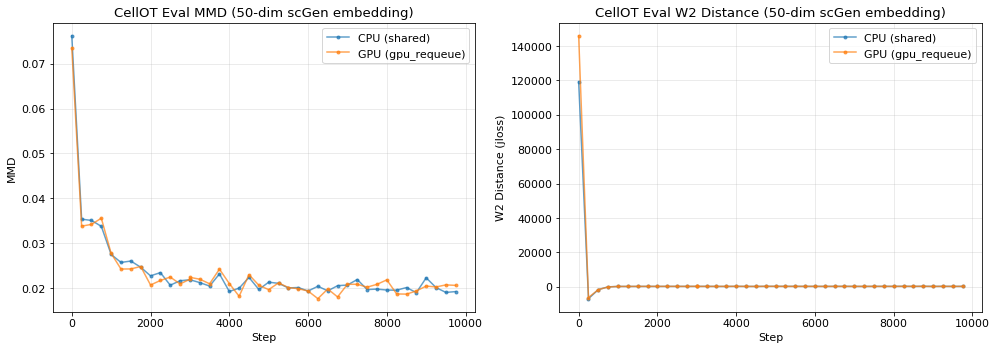

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'CPU (shared)': 'tab:blue', 'GPU (gpu_requeue)': 'tab:orange', 'GPU (gpu)': 'tab:green'}

# MMD
ax = axes[0]
for label, data in race_data.items():
    ev = data['eval']
    ax.plot(ev.index, ev['mmd'], 'o-', ms=3, alpha=0.7, label=label, color=colors[label])
ax.set_xlabel('Step')
ax.set_ylabel('MMD')
ax.set_title('CellOT Eval MMD (50-dim scGen embedding)')
ax.legend()

# W2 distance (jloss)
ax = axes[1]
for label, data in race_data.items():
    ev = data['eval']
    ax.plot(ev.index, ev['jloss'], 'o-', ms=3, alpha=0.7, label=label, color=colors[label])
ax.set_xlabel('Step')
ax.set_ylabel('W2 Distance (jloss)')
ax.set_title('CellOT Eval W2 Distance (50-dim scGen embedding)')
ax.legend()

plt.tight_layout()
plt.savefig('/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/analysis/cellot_race_mmd.png', dpi=150, bbox_inches='tight')
plt.show()

### 7c. Comparison: CellOT with vs without scGen embedding

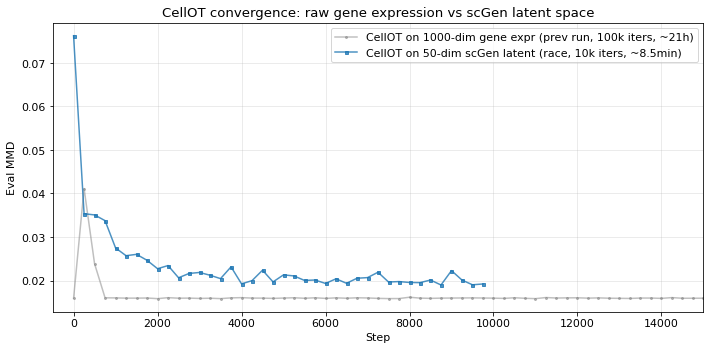

Summary:
  Without scGen: best MMD = 0.015835 at step 2000, total time ~21h
  With scGen:    best MMD = 0.018975 at step 8750, total time ~8.5min


In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Previous CellOT (no scGen, 1000-dim)
ax.plot(cellot_eval.index, cellot_eval['mmd'], 'o-', ms=2, alpha=0.5,
        label='CellOT on 1000-dim gene expr (prev run, 100k iters, ~21h)', color='gray')

# Race CPU (with scGen, 50-dim)
if 'CPU (shared)' in race_data:
    ev = race_data['CPU (shared)']['eval']
    ax.plot(ev.index, ev['mmd'], 's-', ms=3, alpha=0.8,
            label='CellOT on 50-dim scGen latent (race, 10k iters, ~8.5min)', color='tab:blue')

ax.set_xlabel('Step')
ax.set_ylabel('Eval MMD')
ax.set_title('CellOT convergence: raw gene expression vs scGen latent space')
ax.legend()
ax.set_xlim(-500, 15000)

plt.tight_layout()
plt.savefig('/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/analysis/cellot_embedding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Summary:')
print(f'  Without scGen: best MMD = {cellot_eval["mmd"].min():.6f} at step {int(cellot_eval["mmd"].idxmin())}, total time ~21h')
if 'CPU (shared)' in race_data:
    ev = race_data['CPU (shared)']['eval']
    print(f'  With scGen:    best MMD = {ev["mmd"].min():.6f} at step {int(ev["mmd"].idxmin())}, total time ~8.5min')